# Structured Output

In LangChain, structured output refers to the practice of having language models return
responses in a well-defined data format (for example, JSON), rather than free-form text. This
makes the model output easier to parse and work with programmatically.



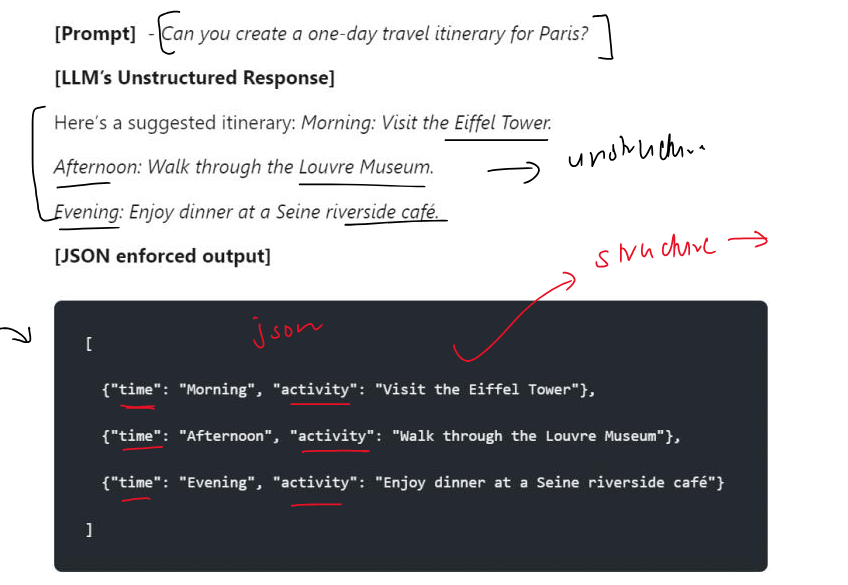

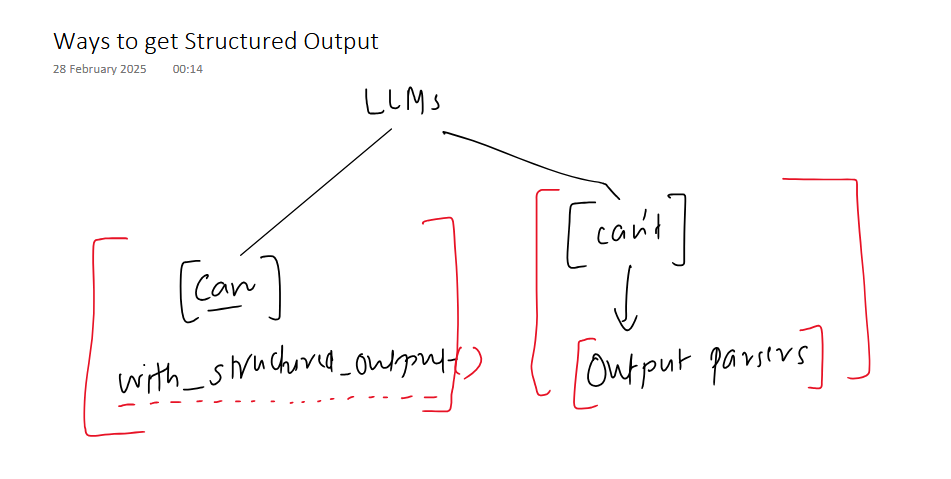

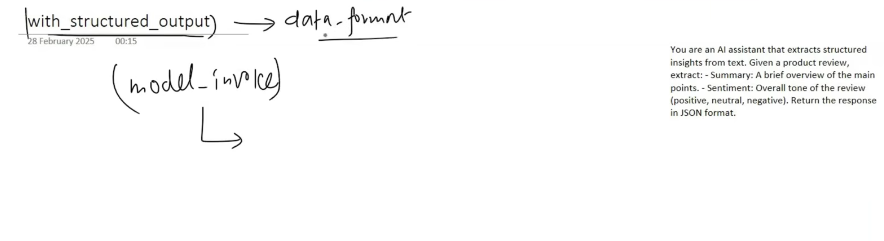

### Structure output

- typedDict
- Pydantic
- Json Schema

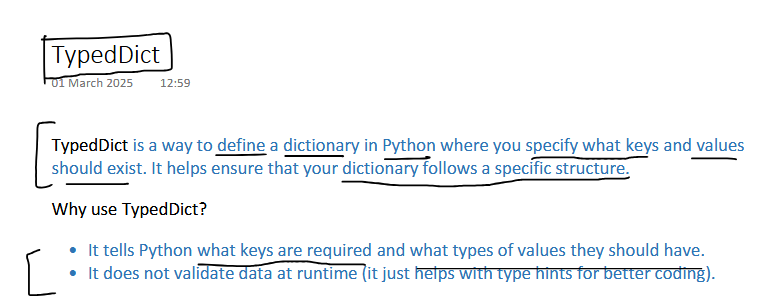

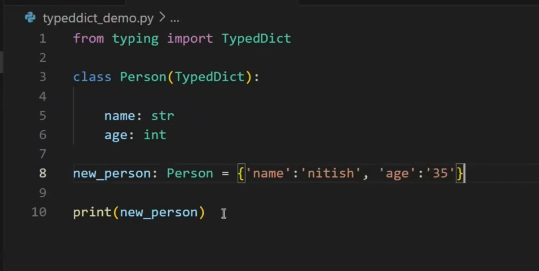

it just tell the user in editor which data type to insert

In [3]:
from typing import TypedDict

class Person(TypedDict):
    name: str
    age: int

new_person: Person ={'name':'Shaniyaz','age':'35'}
print(new_person)

{'name': 'Shaniyaz', 'age': '35'}


#### With Structure Output ( TypedDict )

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal

load_dotenv()

model = ChatOpenAI()

# schema
class Review(TypedDict):

    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    name: Annotated[Optional[str], "Write the name of the reviewer"]
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result['name'])

#### TypedDict with json Schema

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field

load_dotenv()

model = ChatOpenAI()

# schema
json_schema = {
  "title": "Review",
  "type": "object",
  "properties": {
    "key_themes": {
      "type": "array",
      "items": {
        "type": "string"
      },
      "description": "Write down all the key themes discussed in the review in a list"
    },
    "summary": {
      "type": "string",
      "description": "A brief summary of the review"
    },
    "sentiment": {
      "type": "string",
      "enum": ["pos", "neg"],
      "description": "Return sentiment of the review either negative, positive or neutral"
    },
    "pros": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the pros inside a list"
    },
    "cons": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the cons inside a list"
    },
    "name": {
      "type": ["string", "null"],
      "description": "Write the name of the reviewer"
    }
  },
  "required": ["key_themes", "summary", "sentiment"]
}


structured_model = model.with_structured_output(json_schema)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)

#### PyDantic OPENAI

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel, Field

load_dotenv()

model = ChatOpenAI()

# schema
class Review(BaseModel):

    key_themes: list[str] = Field(description="Write down all the key themes discussed in the review in a list")
    summary: str = Field(description="A brief summary of the review")
    sentiment: Literal["pos", "neg"] = Field(description="Return sentiment of the review either negative, positive or neutral")
    pros: Optional[list[str]] = Field(default=None, description="Write down all the pros inside a list")
    cons: Optional[list[str]] = Field(default=None, description="Write down all the cons inside a list")
    name: Optional[str] = Field(default=None, description="Write the name of the reviewer")
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)

#### Pydantic HuggingFace

In [ ]:
from dotenv import load_dotenv
from typing import Optional, Literal
from pydantic import BaseModel, Field
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

# schema
class Review(BaseModel):

    key_themes: list[str] = Field(description="Write down all the key themes discussed in the review in a list")
    summary: str = Field(description="A brief summary of the review")
    sentiment: Literal["pos", "neg"] = Field(description="Return sentiment of the review either negative, positive or neutral")
    pros: Optional[list[str]] = Field(default=None, description="Write down all the pros inside a list")
    cons: Optional[list[str]] = Field(default=None, description="Write down all the cons inside a list")
    name: Optional[str] = Field(default=None, description="Write the name of the reviewer")
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)

In [ ]:
from pydantic import BaseModel, EmailStr, Field
from typing import Optional

class Student(BaseModel):

    name: str = 'nitish'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float = Field(gt=0, lt=10, default=5, description='A decimal value representing the cgpa of the student')


new_student = {'age':'32', 'email':'abc@gmail.com'}

student = Student(**new_student)

student_dict = dict(student)

print(student_dict['age'])

student_json = student.model_dump_json()

In [ ]:
{
    "title": "student",
    "description": "schema about students",
    "type": "object",
    "properties":{
        "name":"string",
        "age":"integer"
    },
    "required":["name"]
}

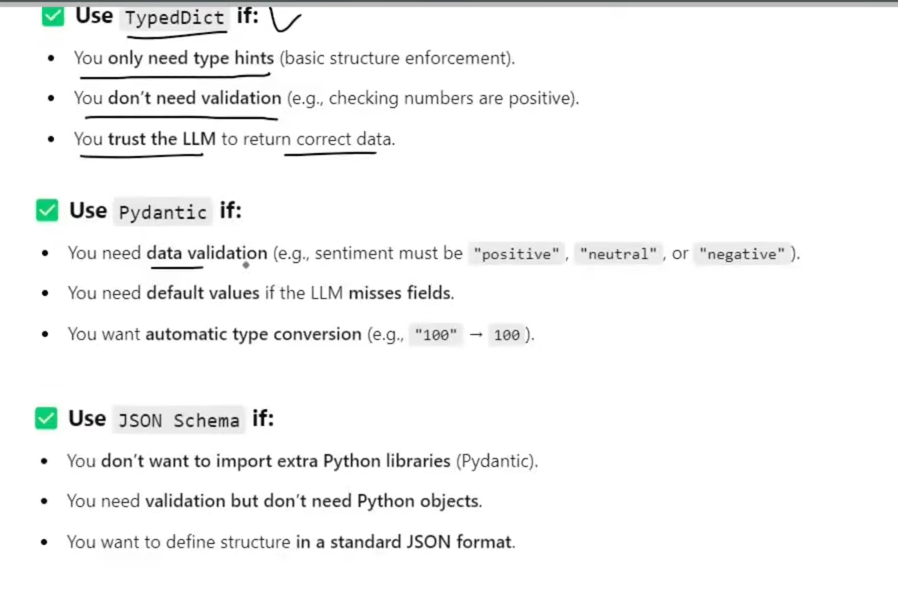

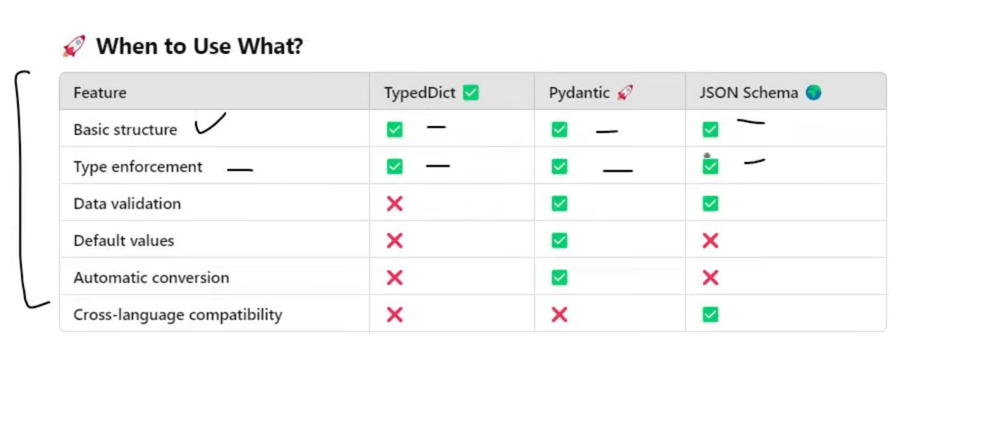